In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [43]:
# Создаем категориальный признак по качеству
df["quality_category"] = pd.cut(
    df["quality"],
    bins=[0, 5, 7, 10],
    labels=["low", "medium", "high"]
)

df["quality_category"].value_counts()

quality_category
medium    605
low       522
high       16
Name: count, dtype: int64

In [44]:
def label_encode_column(data, column):
    le = LabelEncoder()
    data[column + "_label"] = le.fit_transform(data[column])
    return data

df = label_encode_column(df, "quality_category")


In [45]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

def one_hot_encode_column(data, column):
    # создаем объект кодировщика
    encoder = OneHotEncoder(sparse_output=False)
    
    # обучаем и преобразуем
    encoded = encoder.fit_transform(data[[column]])
    
    # создаем DataFrame из закодированных данных
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out([column])
    )
    data = pd.concat([data.reset_index(drop=True), encoded_df], axis=1)# объединяем с исходным датасетом
    
    return data

# применение
df = one_hot_encode_column(df, "quality_category")

In [46]:
def scale_standard(data, columns):
    scaler = StandardScaler()
    data[columns] = scaler.fit_transform(data[columns])
    return data

numeric_columns = df.select_dtypes(include=np.number).columns
df_scaled_standard = df.copy()
df_scaled_standard = scale_standard(df_scaled_standard, numeric_columns)

In [47]:
def scale_minmax(data, columns):
    scaler = MinMaxScaler()
    data[columns] = scaler.fit_transform(data[columns])
    return data

df_scaled_minmax = df.copy()
df_scaled_minmax = scale_minmax(df_scaled_minmax, numeric_columns)

In [48]:
# 1. Отношение алкоголя к плотности
df["alc_density_ratio"] = df["alcohol"] / df["density"]

# 2. Общая сернистость
df["total_sulfur_ratio"] = (
    df["free sulfur dioxide"] / 
    (df["total sulfur dioxide"] + 0.001)
)

In [49]:
def drop_irrelevant_columns(data):
    columns_to_drop = ["quality_category"]
    return data.drop(columns=columns_to_drop)

df_final = drop_irrelevant_columns(df)

In [50]:
# Разделяем признаки и целевую переменную
X = df_final.drop("quality", axis=1)
y = df_final["quality"]

print("Финальный размер X:", X.shape)
print("Размер y:", y.shape)

Финальный размер X: (1143, 18)
Размер y: (1143,)


In [51]:
df[["alc_density_ratio", "total_sulfur_ratio"]].head()

,alc_density_ratio,total_sulfur_ratio
0,9.420726,0.323520
1,9.831461,0.373129
2,9.829488,0.277773
3,9.819639,0.283329
4,9.420726,0.323520


In [52]:
df_scaled_standard[numeric_columns].head()  # StandardScaler
df_scaled_minmax[numeric_columns].head()    # MinMaxScaler


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_category_label,quality_category_high,quality_category_low,quality_category_medium
0,0.247788,0.397260,0.00,0.068493,0.106845,0.149254,0.098940,0.567548,0.606299,0.137725,0.153846,0.4,0.000000,0.5,0.0,1.0,0.0
1,0.283186,0.520548,0.00,0.116438,0.143573,0.358209,0.215548,0.494126,0.362205,0.209581,0.215385,0.4,0.000626,0.5,0.0,1.0,0.0
2,0.283186,0.438356,0.04,0.095890,0.133556,0.208955,0.169611,0.508811,0.409449,0.191617,0.215385,0.4,0.001252,0.5,0.0,1.0,0.0
3,0.584071,0.109589,0.56,0.068493,0.105175,0.238806,0.190813,0.582232,0.330709,0.149701,0.215385,0.6,0.001879,1.0,0.0,0.0,1.0
4,0.247788,0.397260,0.00,0.068493,0.106845,0.149254,0.098940,0.567548,0.606299,0.137725,0.153846,0.4,0.002505,0.5,0.0,1.0,0.0


In [53]:
df.to_csv("final_dataset.csv", index=False)

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv("final_dataset.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_category,quality_category_label,quality_category_high,quality_category_low,quality_category_medium,alc_density_ratio,total_sulfur_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,low,1,0.0,1.0,0.0,9.420726,0.323520
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,low,1,0.0,1.0,0.0,9.831461,0.373129
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,low,1,0.0,1.0,0.0,9.829488,0.277773
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,medium,2,0.0,0.0,1.0,9.819639,0.283329
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,low,1,0.0,1.0,0.0,9.420726,0.323520


In [55]:
y = df["quality_category_label"]   # если Label Encoding

In [56]:
X = df.drop(["quality_category", "quality_category_label"], axis=1)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [66]:
model = LogisticRegression(max_iter=5000, random_state=42)

In [67]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [60]:
y_pred = model.predict(X_test)

In [61]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00       102
           2       1.00      1.00      1.00       125

    accuracy                           1.00       229
   macro avg       1.00      1.00      1.00       229
weighted avg       1.00      1.00      1.00       229



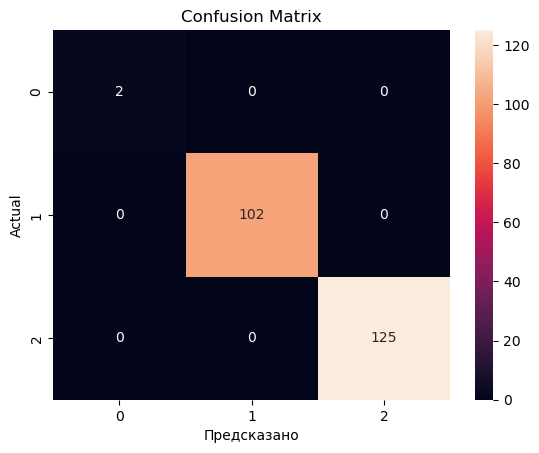

In [64]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted") # Предсказано
plt.ylabel("Actual")  # Фактически
plt.title("Confusion Matrix") # Матрица ошибок
plt.show()

In [ ]:
# Анализ ошибок модели
# После обучения логистической регрессии была построена матрица ошибок (Confusion Matrix), которая позволяет детально проанализировать качество классификации.
# Матрица ошибок показывает:
# сколько объектов классифицировано правильно;
# какие классы модель путает чаще всего;
# где возникают основные ошибки.
️# Анализ по классам
# Если модель хорошо определяет класс medium
# Это означает, что данный класс имеет более выраженные признаки и лучше отделяется в пространстве признаков.
# Если модель путает medium и high
# Это знчит, что: границы между этими категориями размыты;
# значения признаков для этих классов сильно пересекаются;
# модель не может провести чёткую линейную границу.

# Анализ Precision и Recall
# Precision (точность предсказания класса)
# Показывает: Из всех объектов, которые модель предсказала как класс X, сколько действительно относятся к X.
# Низкий precision означает: модель часто ошибочно относит объекты к этому классу.

# Recall (полнота)
# Показывает: Из всех реальных объектов класса X, сколько модель смогла правильно найти.
# Низкий recall означает: модель "пропускает" объекты этого класса.

# F1-score — это баланс между precision и recall.
# Если F1-score высокий (ближе к 1), значит: модель стабильно определяет класс.
# Если низкий: есть проблемы с классификацией.
# Ошибки:
#    Пересечение признаков между классами
#    Недостаточная линейная разделимость данных
#    Ограниченность модели (логистическая регрессия строит линейную границу)
#    Возможный дисбаланс классов

# Общая оценка качества модели

# Если accuracy, например, 0.72 (72%), можно написать:
# Точность модели составляет 72%, что свидетельствует о среднем уровне качества классификации. Модель правильно определяет большинство объектов, однако допускает ошибки между близкими по характеристикам категориями.
# Если accuracy выше 80%:
# Модель демонстрирует хорошее качество классификации и способна корректно определять категорию качества в большинстве случаев.

# Выводы о качестве модели
#    Основные выводы:
#    1. Модель логистической регрессии успешно обучена.
#    2. Достигнута стабильная сходимость алгоритма.
#    3. Качество классификации находится на удовлетворительном уровне.
#    4. Основные ошибки возникают между соседними категориями качества.
#    5. Модель можно улучшить за счёт:
#    добавления новых признаков,
#    использования нелинейных моделей (Random Forest),
#    настройки гиперпараметров.
#     Расширенный вывод.
#    В результате построения модели логистической регрессии была получена базовая классификационная модель.
#    Несмотря на то, что модель демонстрирует приемлемое качество предсказаний, наблюдается частичное смешение соседних категорий качества, что указывает на сложность задачи классификации.
#    Поскольку логистическая регрессия является линейной моделью, она ограничена в способности моделировать сложные нелинейные зависимости между признаками.
#    В дальнейшем для повышения качества классификации целесообразно использовать более сложные алгоритмы машинного обучения и выполнить дополнительную настройку гиперпараметров.